# Hyperliquid 펀딩비 분석
### FundingCarryBond 수익성 검증
> 데이터 출처: Hyperliquid REST API (`fundingHistory`)

In [152]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from matplotlib import font_manager
from datetime import datetime, timezone
import warnings
warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 (Windows) ─────────────────────────
import matplotlib
import platform

def set_korean_font():
    if platform.system() == 'Windows':
        candidates = ['Malgun Gothic', 'NanumGothic', 'AppleGothic', 'Gulim']
    elif platform.system() == 'Darwin':
        candidates = ['AppleGothic', 'NanumGothic', 'Malgun Gothic']
    else:
        candidates = ['NanumGothic', 'NanumBarunGothic', 'Malgun Gothic']

    available = {f.name for f in font_manager.fontManager.ttflist}
    for font in candidates:
        if font in available:
            matplotlib.rc('font', family=font)
            print(f'한글 폰트: {font}')
            return font

    # 폴백: 시스템 폰트 직접 지정 (Windows)
    try:
        font_path = 'C:/Windows/Fonts/malgun.ttf'
        font_manager.fontManager.addfont(font_path)
        prop = font_manager.FontProperties(fname=font_path)
        matplotlib.rc('font', family=prop.get_name())
        print(f'한글 폰트 직접 로드: {font_path}')
        return prop.get_name()
    except Exception:
        pass

    print('⚠️  한글 폰트 없음 — 영문으로 대체됩니다')
    return None

set_korean_font()
matplotlib.rcParams['axes.unicode_minus'] = False   # 마이너스 깨짐 방지

# ── 공통 스타일 ──────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0d1117',
    'axes.facecolor':    '#161b22',
    'axes.edgecolor':    '#30363d',
    'axes.labelcolor':   '#e6edf3',
    'xtick.color':       '#8b949e',
    'ytick.color':       '#8b949e',
    'text.color':        '#e6edf3',
    'grid.color':        '#21262d',
    'grid.linestyle':    '--',
    'grid.alpha':        0.6,
    'font.size':         11,
})

print('라이브러리 로드 완료')


한글 폰트: Malgun Gothic
라이브러리 로드 완료


In [153]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  설정값  —  여기만 바꾸면 됨
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
COINS        = ['BTC', 'ETH', 'HYPE']   # 분석할 코인
DAYS         = 180                       # 조회 기간 (일)
TARGET_APY   = 8.0                       # FundingCarryBond 목표 쿠폰 (%)
ENTRY_FEE_BP = 11.5                      # 진입·청산 왕복 비용 (bp)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

HL_API = 'https://api.hyperliquid.xyz/info'

# HL fundingHistory API 특성:
#   - 8시간마다 1건 반환 (3건/일)
#   - 각 fundingRate 값 = 1시간 지급 요율 (8h 총액의 1/8)
#   - 연환산: fundingRate × 24h × 365일 = × 8,760
#   - 검증: 현재 BTC 0.0013% × 8,760 = 11.4% ≈ UI Annualized 10.95% ✓
#   - 누적 계산 시: fundingRate × 8 (8h 대표값) × 건수
PER_YEAR       = 24 * 365   # = 8,760  (1시간 요율 기준 연환산)
HOURS_PER_TICK = 8           # 각 데이터 1건이 대표하는 시간 (8h)

print(f'설정: {COINS} / {DAYS}일 / 목표쿠폰 {TARGET_APY}%')
print(f'PER_YEAR = {PER_YEAR}  |  HOURS_PER_TICK = {HOURS_PER_TICK}')


설정: ['BTC', 'ETH', 'HYPE'] / 180일 / 목표쿠폰 8.0%
PER_YEAR = 8760  |  HOURS_PER_TICK = 8


In [154]:
def fetch(coin, days):
    """HL API는 1회 최대 500건 제한 → 페이지네이션으로 전체 조회"""
    end_ms   = int(datetime.now(timezone.utc).timestamp() * 1000)
    start_ms = end_ms - days * 86400 * 1000
    all_rows = []

    while True:
        res = requests.post(HL_API, json={
            'type':      'fundingHistory',
            'coin':      coin,
            'startTime': start_ms,
            'endTime':   end_ms,
        }, timeout=15)
        res.raise_for_status()
        batch = res.json()
        if not batch:
            break
        all_rows.extend(batch)
        if len(batch) < 500:          # 마지막 페이지
            break
        end_ms = batch[0]['time'] - 1 # 다음 요청: 가장 오래된 것보다 이전

    if not all_rows:
        raise ValueError(f'{coin}: 데이터 없음')

    df = pd.DataFrame(all_rows)
    df = df.drop_duplicates('time').sort_values('time').reset_index(drop=True)
    df['time']        = pd.to_datetime(df['time'], unit='ms', utc=True)
    df['fundingRate'] = df['fundingRate'].astype(float)
    df['premium']     = df.get('premium', pd.Series(0, index=df.index)).astype(float)
    df['ann_rate']    = df['fundingRate'] * PER_YEAR * 100
    df['cumulative']  = df['fundingRate'].cumsum() * HOURS_PER_TICK * 100
    df['coin']        = coin
    return df.set_index('time')

data = {}
for coin in COINS:
    print(f'  {coin} 수집 중...', end=' ')
    data[coin] = fetch(coin, DAYS)
    n = len(data[coin])
    interval_h = DAYS * 24 / n
    print(f'{n}건  (≈ {interval_h:.1f}시간 간격)')

print('\n✅ 수집 완료')


  BTC 수집 중... 500건  (≈ 8.6시간 간격)
  ETH 수집 중... 500건  (≈ 8.6시간 간격)
  HYPE 수집 중... 500건  (≈ 8.6시간 간격)

✅ 수집 완료


In [155]:
rows = []
for coin, df in data.items():
    r = df['fundingRate']
    recent = r.iloc[-90:]   # 최근 30일 (90 = 3회×30일)

    # 최대 연속 음수 구간
    streak = max_s = 0
    for v in r:
        streak = (streak + 1) if v < 0 else 0
        max_s = max(max_s, streak)

    rows.append({
        '코인':             coin,
        '데이터(건)':       len(r),
        '연환산 수익(%)':   round(r.mean() * PER_YEAR * 100, 2),
        '최근30일 연환산(%)': round(recent.mean() * PER_YEAR * 100, 2),
        '연 변동성(%)':     round(r.std() * (PER_YEAR**0.5) * 100, 2),
        'Sharpe':           round((r.mean() * PER_YEAR) / (r.std() * PER_YEAR**0.5), 2) if r.std() > 0 else 0,
        '양수 비율(%)':     round((r > 0).mean() * 100, 1),
        '최대연속음수(회)': max_s,
        '8h 최소(%)':       round(r.min() * 100, 4),
        '8h 최대(%)':       round(r.max() * 100, 4),
        '누적 수익(%)':     round(r.sum() * 100, 2),
    })

stats = pd.DataFrame(rows).set_index('코인')
stats

,데이터(건),연환산 수익(%),최근30일 연환산(%),연 변동성(%),Sharpe,양수 비율(%),최대연속음수(회),8h 최소(%),8h 최대(%),누적 수익(%)
코인,,,,,,,,,,
BTC,500,7.79,10.44,0.06,126.48,88.4,18,-0.0018,0.0012,0.44
ETH,500,9.09,8.15,0.05,199.93,94.8,10,-0.0012,0.0038,0.52
HYPE,500,12.09,11.98,0.07,185.78,99.8,1,-0.0004,0.0106,0.69


## 1. 8시간 펀딩비 히스토리 (Bar Chart)

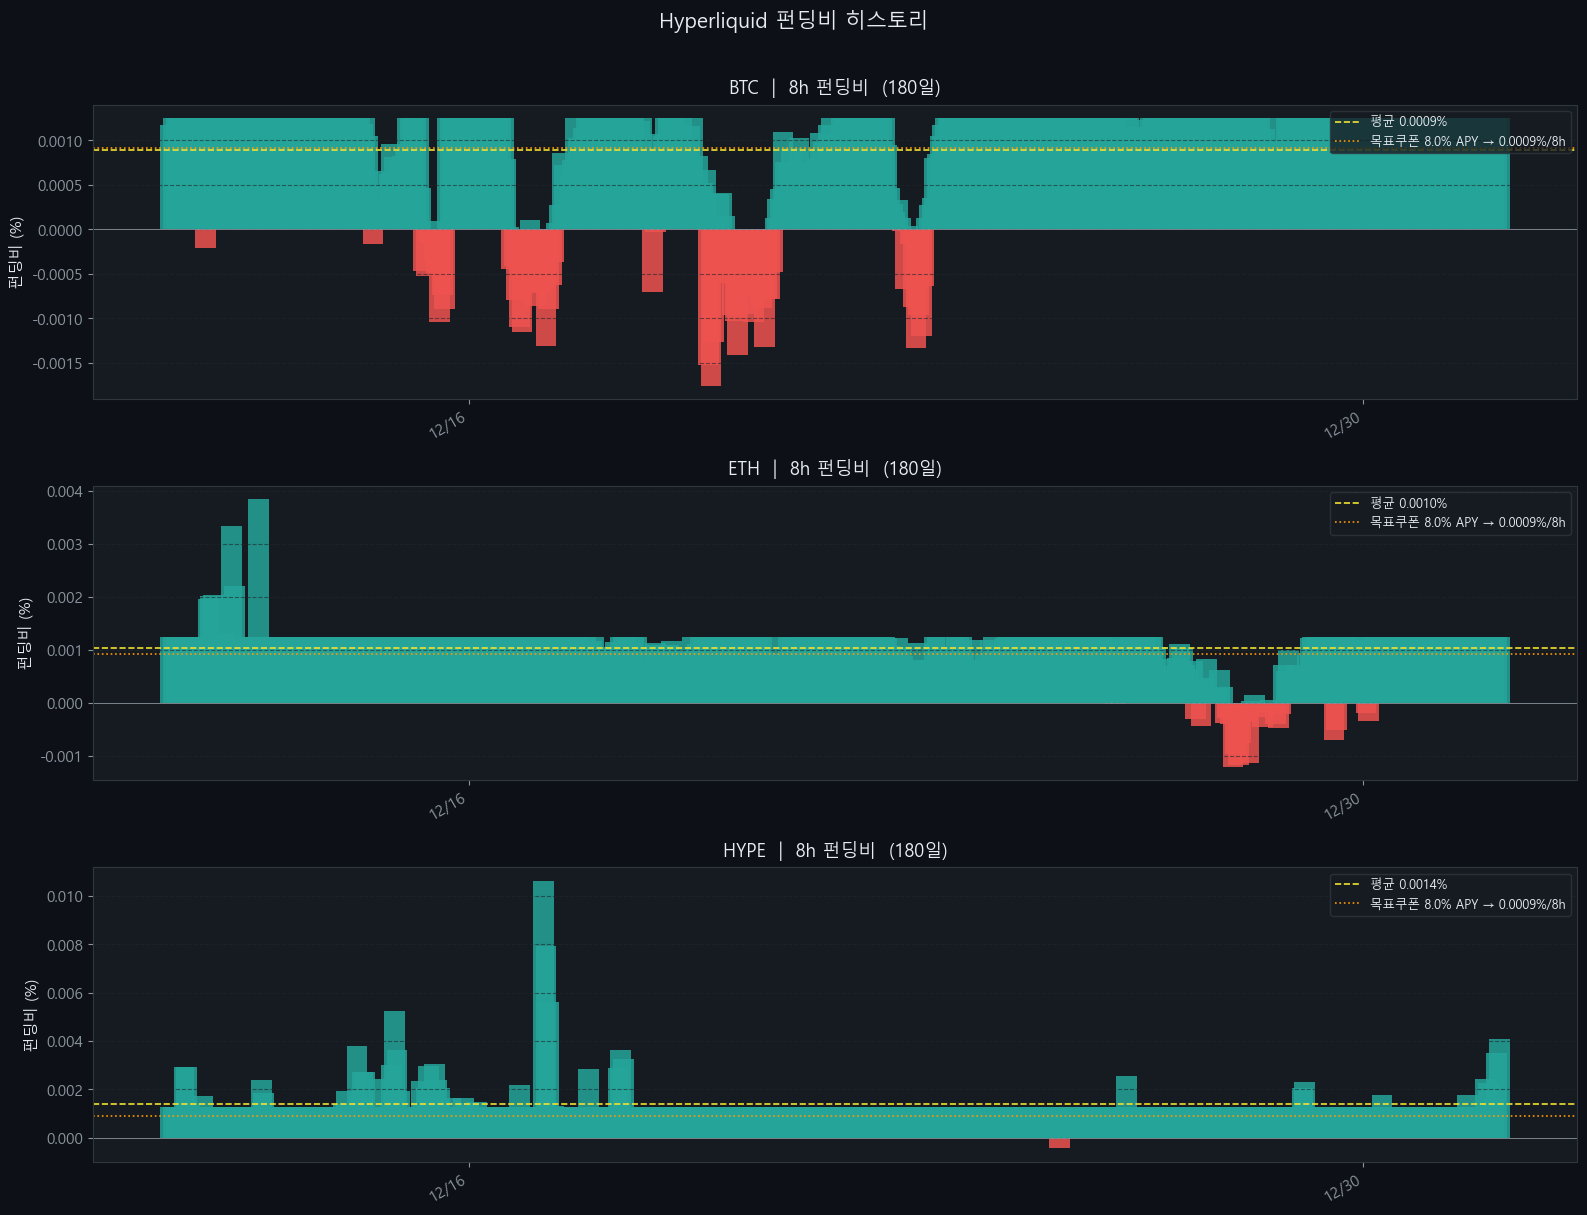

In [156]:
n = len(COINS)
fig, axes = plt.subplots(n, 1, figsize=(16, 4 * n))
if n == 1: axes = [axes]

for ax, coin in zip(axes, COINS):
    df  = data[coin]
    col = ['#26a69a' if v >= 0 else '#ef5350' for v in df['fundingRate']]
    ax.bar(df.index, df['fundingRate'] * 100, color=col,
           width=pd.Timedelta(hours=7.8), alpha=0.85)

    mean_val = df['fundingRate'].mean() * 100
    target   = TARGET_APY / 100 / PER_YEAR * 100   # 쿠폰의 8h 환산 %
    ax.axhline(mean_val, color='#f0e130', lw=1.2, ls='--',
               label=f'평균 {mean_val:.4f}%')
    ax.axhline(target,   color='#ff9800', lw=1.2, ls=':',
               label=f'목표쿠폰 {TARGET_APY}% APY → {target:.4f}%/8h')
    ax.axhline(0, color='#8b949e', lw=0.6)

    ax.set_title(f'{coin}  |  8h 펀딩비  ({DAYS}일)', fontsize=13, pad=8)
    ax.set_ylabel('펀딩비 (%)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    ax.legend(loc='upper right', fontsize=9,
              facecolor='#161b22', edgecolor='#30363d')
    ax.grid(True, axis='y')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle('Hyperliquid 펀딩비 히스토리', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('chart_funding_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. 누적 수익 곡선 (Cumulative Return)

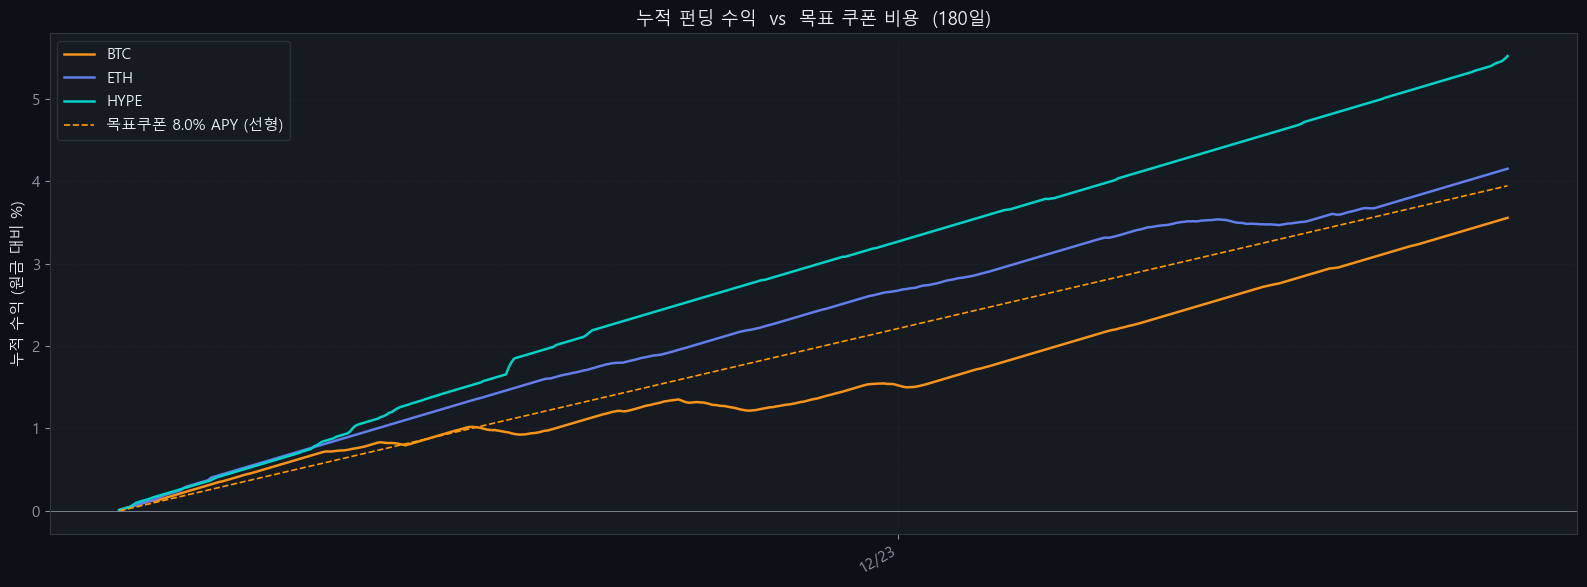

In [157]:
COLORS = {'BTC': '#f7931a', 'ETH': '#627eea', 'HYPE': '#00d4c8',
          'SOL': '#9945ff', 'ARB': '#28a0f0', 'AVAX': '#e84142'}

fig, ax = plt.subplots(figsize=(16, 6))

for coin, df in data.items():
    color = COLORS.get(coin, '#aaaaaa')
    ax.plot(df.index, df['cumulative'],
            label=coin, color=color, lw=1.8)

# 목표쿠폰 선 (원금 대비 누적 쿠폰 비용)
ref_df = list(data.values())[0]
n_pts  = len(ref_df)
coupon_line = np.linspace(0, TARGET_APY / 100 * DAYS / 365 * 100, n_pts)
ax.plot(ref_df.index, coupon_line,
        color='#ff9800', lw=1.2, ls='--',
        label=f'목표쿠폰 {TARGET_APY}% APY (선형)')

ax.axhline(0, color='#8b949e', lw=0.6)
ax.set_title(f'누적 펀딩 수익  vs  목표 쿠폰 비용  ({DAYS}일)', fontsize=13)
ax.set_ylabel('누적 수익 (원금 대비 %)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.legend(facecolor='#161b22', edgecolor='#30363d')
ax.grid(True)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('chart_cumulative.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 연환산 수익률 롤링 평균 (30일 이동평균)

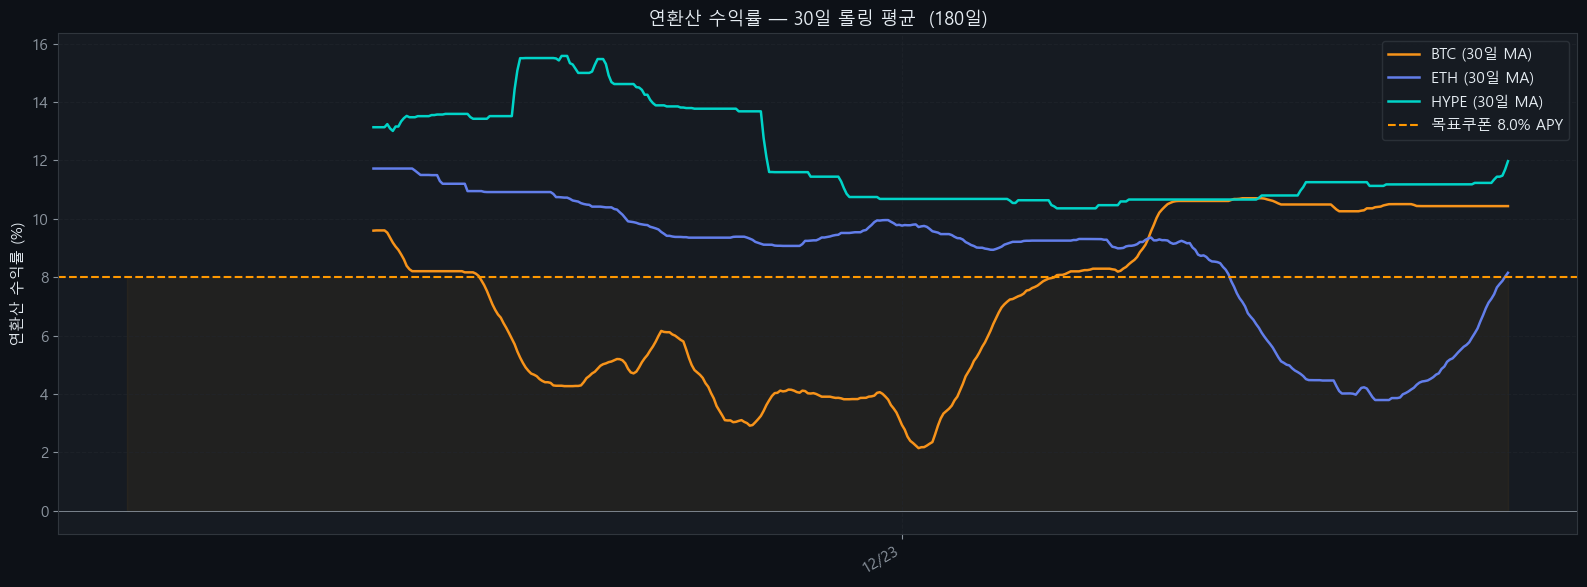

In [158]:
WINDOW = 90   # 30일 = 90개 (8h × 3 × 30)

fig, ax = plt.subplots(figsize=(16, 6))

for coin, df in data.items():
    color   = COLORS.get(coin, '#aaaaaa')
    rolling = df['fundingRate'].rolling(WINDOW).mean() * PER_YEAR * 100
    ax.plot(df.index, rolling, label=f'{coin} (30일 MA)',
            color=color, lw=1.8)

ax.axhline(TARGET_APY, color='#ff9800', lw=1.5, ls='--',
           label=f'목표쿠폰 {TARGET_APY}% APY')
ax.axhline(0, color='#8b949e', lw=0.6)
ax.fill_between(list(data.values())[0].index, 0, TARGET_APY,
                alpha=0.05, color='#ff9800')

ax.set_title(f'연환산 수익률 — 30일 롤링 평균  ({DAYS}일)', fontsize=13)
ax.set_ylabel('연환산 수익률 (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.legend(facecolor='#161b22', edgecolor='#30363d')
ax.grid(True)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('chart_rolling_apy.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 펀딩비 분포 (Histogram + KDE)

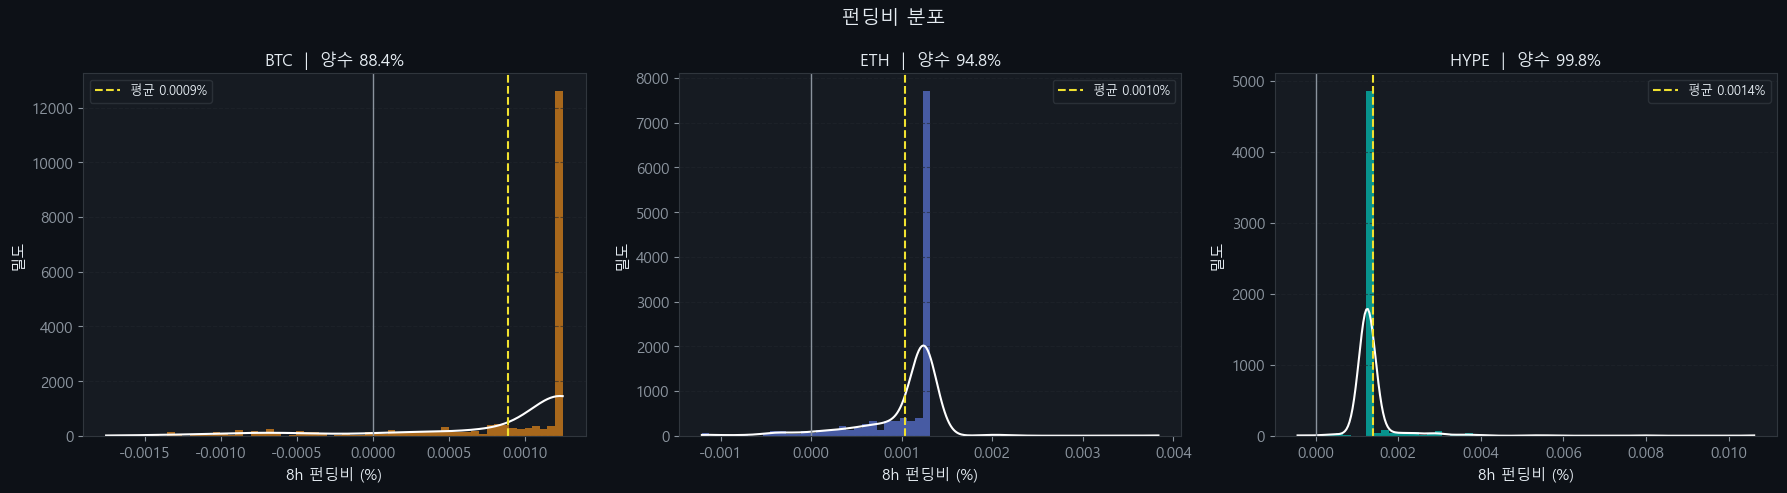

In [159]:
n = len(COINS)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
if n == 1: axes = [axes]

for ax, coin in zip(axes, COINS):
    df    = data[coin]
    rates = df['fundingRate'] * 100
    color = COLORS.get(coin, '#26a69a')

    ax.hist(rates, bins=60, color=color, alpha=0.65,
            edgecolor='none', density=True)

    # KDE (수동 계산)
    from scipy.stats import gaussian_kde
    try:
        kde  = gaussian_kde(rates)
        xs   = np.linspace(rates.min(), rates.max(), 300)
        ax.plot(xs, kde(xs), color='white', lw=1.5)
    except Exception:
        pass

    ax.axvline(rates.mean(), color='#f0e130', lw=1.5, ls='--',
               label=f'평균 {rates.mean():.4f}%')
    ax.axvline(0, color='#8b949e', lw=1)

    pos_pct = (rates > 0).mean() * 100
    ax.set_title(f'{coin}  |  양수 {pos_pct:.1f}%', fontsize=12)
    ax.set_xlabel('8h 펀딩비 (%)')
    ax.set_ylabel('밀도')
    ax.legend(fontsize=9, facecolor='#161b22', edgecolor='#30363d')
    ax.grid(True, axis='y')

fig.suptitle('펀딩비 분포', fontsize=14)
plt.tight_layout()
plt.savefig('chart_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. FundingCarryBond 시뮬레이션 — Reserve 잔고 추이

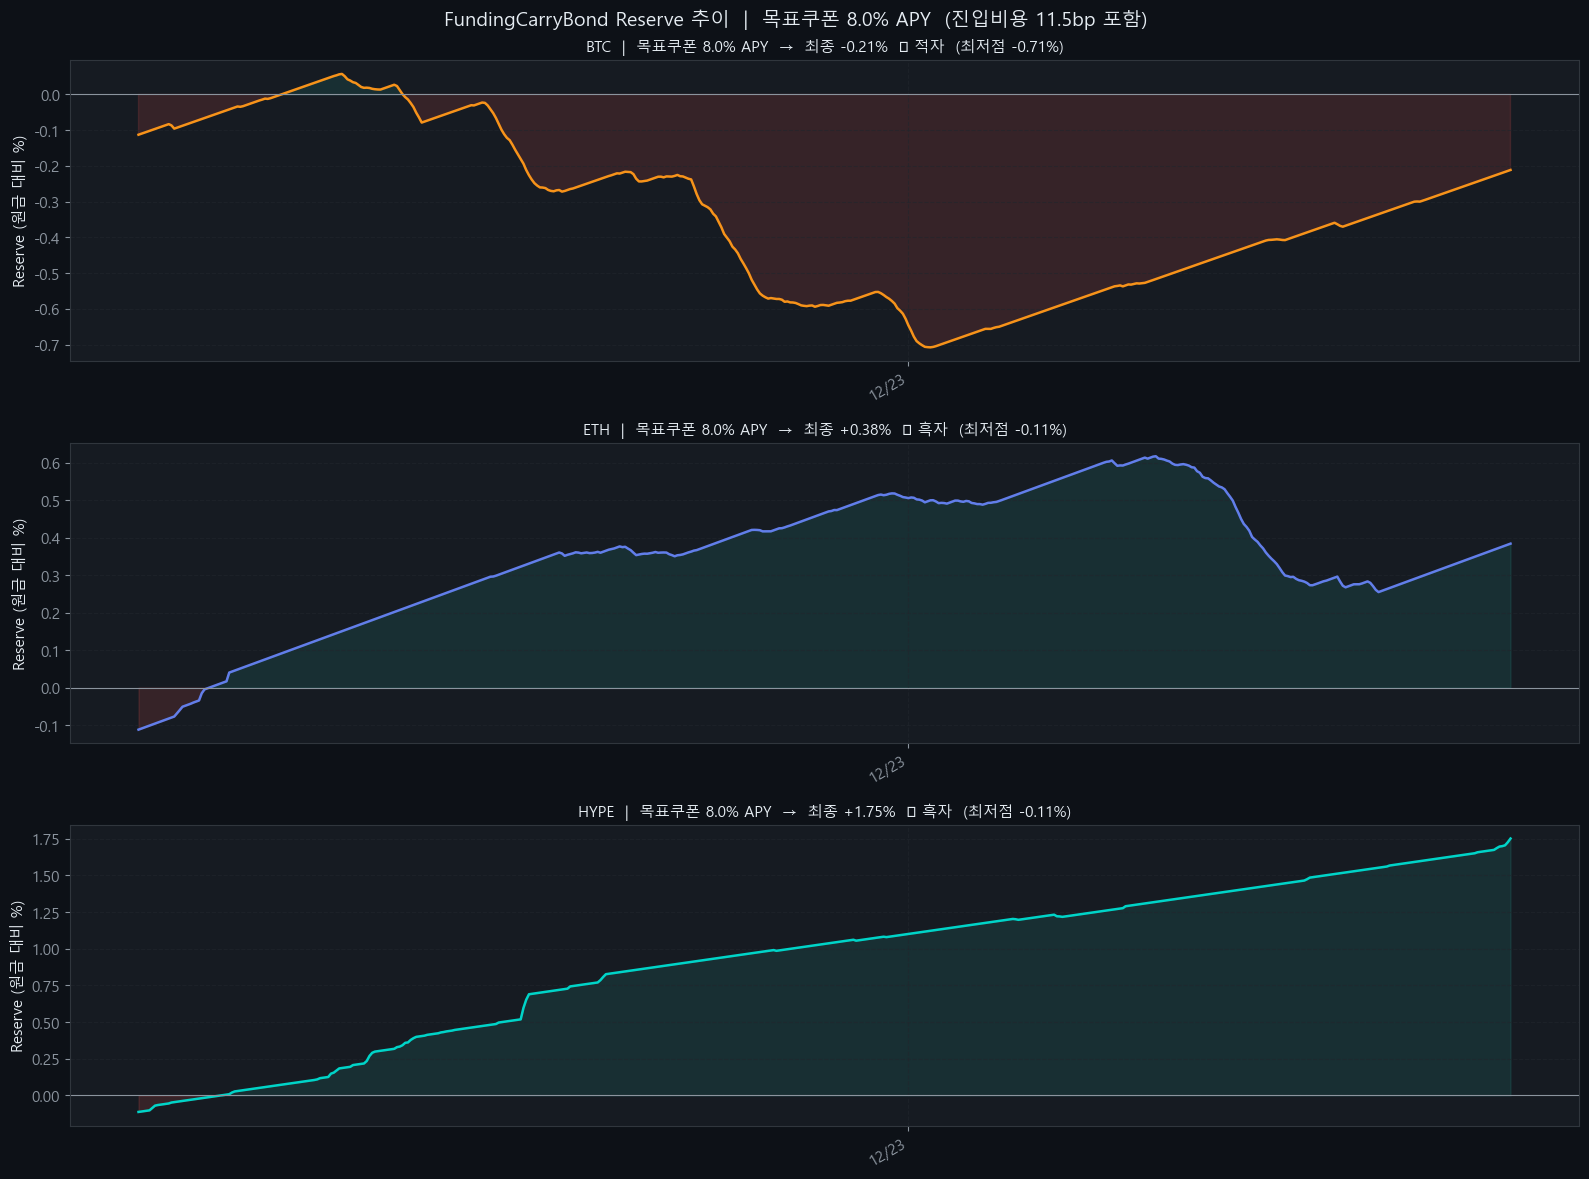


── 시뮬레이션 결과 요약 ──


,최종 Reserve(%),최저점(%),판단
코인,,,
BTC,-0.21,-0.71,❌ 적자
ETH,0.38,-0.11,✅ 흑자
HYPE,1.75,-0.11,✅ 흑자


In [160]:
fee_cost  = ENTRY_FEE_BP / 10000   # 원금 대비 진입비용
# 각 틱에서 필요한 수익: 연 목표 / PER_YEAR × HOURS_PER_TICK
coupon_per_tick = TARGET_APY / 100 / PER_YEAR * HOURS_PER_TICK

fig, axes = plt.subplots(len(COINS), 1, figsize=(16, 4 * len(COINS)))
if len(COINS) == 1: axes = [axes]

summary = []

for ax, coin in zip(axes, COINS):
    df     = data[coin]
    rates  = df['fundingRate'].values
    times  = df.index

    # Reserve = 실제 펀딩 수익(×8h) - 쿠폰 비용(×8h) - 초기 수수료
    net_per_tick = rates * HOURS_PER_TICK - coupon_per_tick
    reserve      = np.cumsum(net_per_tick) * 100 - fee_cost * 100

    color = COLORS.get(coin, '#26a69a')
    ax.plot(times, reserve, color=color, lw=1.8, label=coin)
    ax.fill_between(times, reserve, 0,
                    where=(reserve >= 0), alpha=0.15, color='#26a69a')
    ax.fill_between(times, reserve, 0,
                    where=(reserve <  0), alpha=0.15, color='#ef5350')
    ax.axhline(0, color='#8b949e', lw=0.8)

    final   = reserve[-1]
    min_val = reserve.min()
    verdict = '✅ 흑자' if final > 0 else '❌ 적자'
    ax.set_title(
        f'{coin}  |  목표쿠폰 {TARGET_APY}% APY  →  최종 {final:+.2f}%  {verdict}  '
        f'(최저점 {min_val:.2f}%)',
        fontsize=11
    )
    ax.set_ylabel('Reserve (원금 대비 %)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    ax.grid(True)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    summary.append({'코인': coin, '최종 Reserve(%)': round(final, 2),
                    '최저점(%)': round(min_val, 2), '판단': verdict})

fig.suptitle(
    f'FundingCarryBond Reserve 추이  |  목표쿠폰 {TARGET_APY}% APY  '
    f'(진입비용 {ENTRY_FEE_BP}bp 포함)',
    fontsize=14
)
plt.tight_layout()
plt.savefig('chart_reserve.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── 시뮬레이션 결과 요약 ──')
pd.DataFrame(summary).set_index('코인')


## 6. 최대 감내 가능 쿠폰률 (Break-even APY)

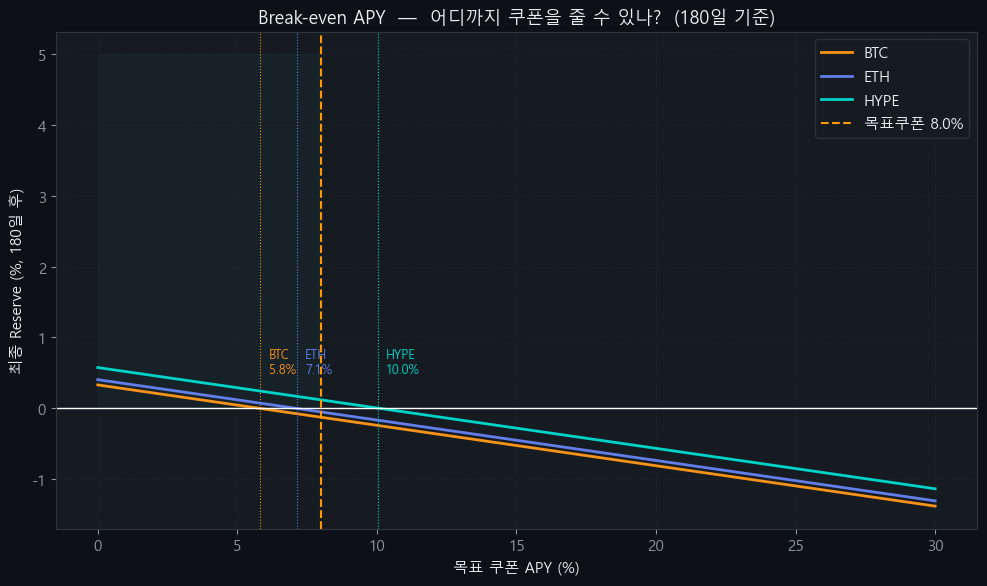

In [161]:
fig, ax = plt.subplots(figsize=(10, 6))

coupon_range = np.linspace(0, 30, 300)   # 0 ~ 30% APY

for coin in COINS:
    color     = COLORS.get(coin, '#aaaaaa')
    rates_sum = data[coin]['fundingRate'].sum()
    n_pts     = len(data[coin])

    # 각 목표쿠폰별 최종 Reserve
    final_reserves = [
        (rates_sum - (apy / 100 / PER_YEAR) * n_pts) * 100 - fee_cost * 100
        for apy in coupon_range
    ]
    ax.plot(coupon_range, final_reserves, color=color, lw=2, label=coin)

    # Break-even 표시
    be_idx = np.argmin(np.abs(final_reserves))
    be_apy = coupon_range[be_idx]
    ax.axvline(be_apy, color=color, lw=0.8, ls=':')
    ax.text(be_apy + 0.3, 0.5, f'{coin}\n{be_apy:.1f}%', color=color, fontsize=9)

ax.axhline(0, color='white', lw=1)
ax.axvline(TARGET_APY, color='#ff9800', lw=1.5, ls='--',
           label=f'목표쿠폰 {TARGET_APY}%')
ax.fill_between(coupon_range, 0, 5,
                where=(np.array(coupon_range) <= TARGET_APY),
                alpha=0.05, color='#26a69a')

ax.set_xlabel('목표 쿠폰 APY (%)')
ax.set_ylabel(f'최종 Reserve (%, {DAYS}일 후)')
ax.set_title(f'Break-even APY  —  어디까지 쿠폰을 줄 수 있나?  ({DAYS}일 기준)',
             fontsize=13)
ax.legend(facecolor='#161b22', edgecolor='#30363d')
ax.grid(True)
plt.tight_layout()
plt.savefig('chart_breakeven.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 종합 요약

---
## 8. FundingCarryBond 백테스트

In [162]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  백테스트 파라미터
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BT_COINS       = ['BTC', 'ETH', 'HYPE']
BT_TARGET_APY  = 8.0
BT_MATURITY    = 30
BT_COUPON_DAYS = [21, 28]
BT_LEVERAGES   = [1, 2, 3]
BT_RESERVES    = [0.05, 0.10, 0.20]   # Reserve 비율 비교

FEE_RATE_PER_SIDE = 0.00085
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

assert BT_MATURITY <= DAYS

P             = 1.0
N_COUPONS     = len(BT_COUPON_DAYS)
TOTAL_COUPON  = P * BT_TARGET_APY / 100 * BT_MATURITY / 365
COUPON_PERIOD = TOTAL_COUPON / N_COUPONS

print(f'만기 {BT_MATURITY}일  |  쿠폰 Day {BT_COUPON_DAYS}  |  APY {BT_TARGET_APY}%')
print(f'회당 쿠폰액 = {COUPON_PERIOD*100:.4f}%  |  총 쿠폰 = {TOTAL_COUPON*100:.4f}%')
print()
print(f'{"Reserve":>8}  {"청산트리거 (V<)":>16}  {"버퍼 (R - 쿠폰의무)"}')
print('-' * 50)
for r_ratio in BT_RESERVES:
    R_amt    = P * r_ratio
    liq      = P + COUPON_PERIOD
    buffer   = R_amt - TOTAL_COUPON
    print(f'{r_ratio*100:>7.0f}%  {liq:>16.6f}  {buffer*100:>+.4f}%  ({buffer/R_amt*100:.1f}% of R)')


만기 30일  |  쿠폰 Day [21, 28]  |  APY 8.0%
회당 쿠폰액 = 0.3288%  |  총 쿠폰 = 0.6575%

 Reserve        청산트리거 (V<)  버퍼 (R - 쿠폰의무)
--------------------------------------------------
      5%          1.003288  +4.3425%  (86.8% of R)
     10%          1.003288  +9.3425%  (93.4% of R)
     20%          1.003288  +19.3425%  (96.7% of R)


In [163]:
def run_backtest(coin, leverage, r_ratio):
    R         = P * r_ratio
    TOTAL_CAP = P + R
    LIQ_THRESHOLD = P + COUPON_PERIOD

    df = data[coin].copy()
    ticks_per_day = 24 / HOURS_PER_TICK
    max_ticks     = int(BT_MATURITY * ticks_per_day)
    df = df.iloc[:max_ticks]

    notional   = TOTAL_CAP * leverage / (1 + leverage)
    entry_cost = FEE_RATE_PER_SIDE * 2 * notional

    V             = TOTAL_CAP - entry_cost
    days_acc      = 0.0
    coupons_paid  = 0
    liquidated    = False
    liq_idx       = None
    V_series      = []
    coupon_events = []
    coupon_idx    = 0
    EPS           = 1e-9

    for i, (ts, row) in enumerate(df.iterrows()):
        V        += row['fundingRate'] * HOURS_PER_TICK * notional
        days_acc += HOURS_PER_TICK / 24

        while (coupon_idx < N_COUPONS and
               days_acc >= BT_COUPON_DAYS[coupon_idx] - EPS):
            V -= COUPON_PERIOD
            coupons_paid += 1
            coupon_events.append(ts)
            coupon_idx += 1

        if not liquidated and V < LIQ_THRESHOLD:
            liquidated = True
            liq_idx    = i

        V_series.append(V)

    if not liquidated:
        while coupons_paid < N_COUPONS:
            V -= COUPON_PERIOD
            coupons_paid += 1
            coupon_events.append(df.index[-1])
        V -= P
        if V_series:
            V_series[-1] = V

    return {
        'liquidated':   liquidated,
        'liq_time':     df.index[liq_idx] if liq_idx is not None else None,
        'final_V':      V_series[-1] if V_series else 0,
        'coupons_paid': coupons_paid,
        'R':            R,
        'TOTAL_CAP':    TOTAL_CAP,
        'notional':     notional,
    }

# ── Reserve × 레버리지 × 코인 ────────────────────────────
print(f'만기 {BT_MATURITY}일  |  쿠폰 Day {BT_COUPON_DAYS}  |  APY {BT_TARGET_APY}%\n')

for coin in BT_COINS:
    print(f'━━━ {coin} ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
    print(f'  {"Reserve":>8}  {"레버":>5}  {"노셔널":>8}  {"결과":<8}  {"ROI(30일)":>10}  {"ROI(연환산)":>11}')
    print(f'  ' + '-' * 62)

    for r_ratio in BT_RESERVES:
        for lev in BT_LEVERAGES:
            r = run_backtest(coin, lev, r_ratio)
            flag = '❌청산' if r['liquidated'] else '✅만기'
            if not r['liquidated']:
                roi_30  = (r['final_V'] - r['R']) / r['R'] * 100
                roi_ann = roi_30 * 365 / BT_MATURITY
                roi_30_str  = f"{roi_30:+.2f}%"
                roi_ann_str = f"{roi_ann:+.1f}%"
            else:
                roi_30_str = roi_ann_str = '-'
            print(f'  {r_ratio*100:>7.0f}%  {lev:>4}x  {r["notional"]:>8.4f}  {flag:<8}  {roi_30_str:>10}  {roi_ann_str:>11}')
        print()


만기 30일  |  쿠폰 Day [21, 28]  |  APY 8.0%

━━━ BTC ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Reserve     레버       노셔널  결과          ROI(30일)     ROI(연환산)
  --------------------------------------------------------------
        5%     1x    0.5250  ✅만기           -6.65%       -81.0%
        5%     2x    0.7000  ✅만기           -4.49%       -54.6%
        5%     3x    0.7875  ✅만기           -3.41%       -41.4%

       10%     1x    0.5500  ✅만기           -3.17%       -38.6%
       10%     2x    0.7333  ✅만기           -2.04%       -24.8%
       10%     3x    0.8250  ✅만기           -1.47%       -17.9%

       20%     1x    0.6000  ✅만기           -1.43%       -17.4%
       20%     2x    0.8000  ✅만기           -0.81%        -9.9%
       20%     3x    0.9000  ✅만기           -0.50%        -6.1%

━━━ ETH ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Reserve     레버       노셔널  결과          ROI(30일)     ROI(연환산)
  --------------------------------------------------------------
        5%     1x    0.5250  ✅만기 

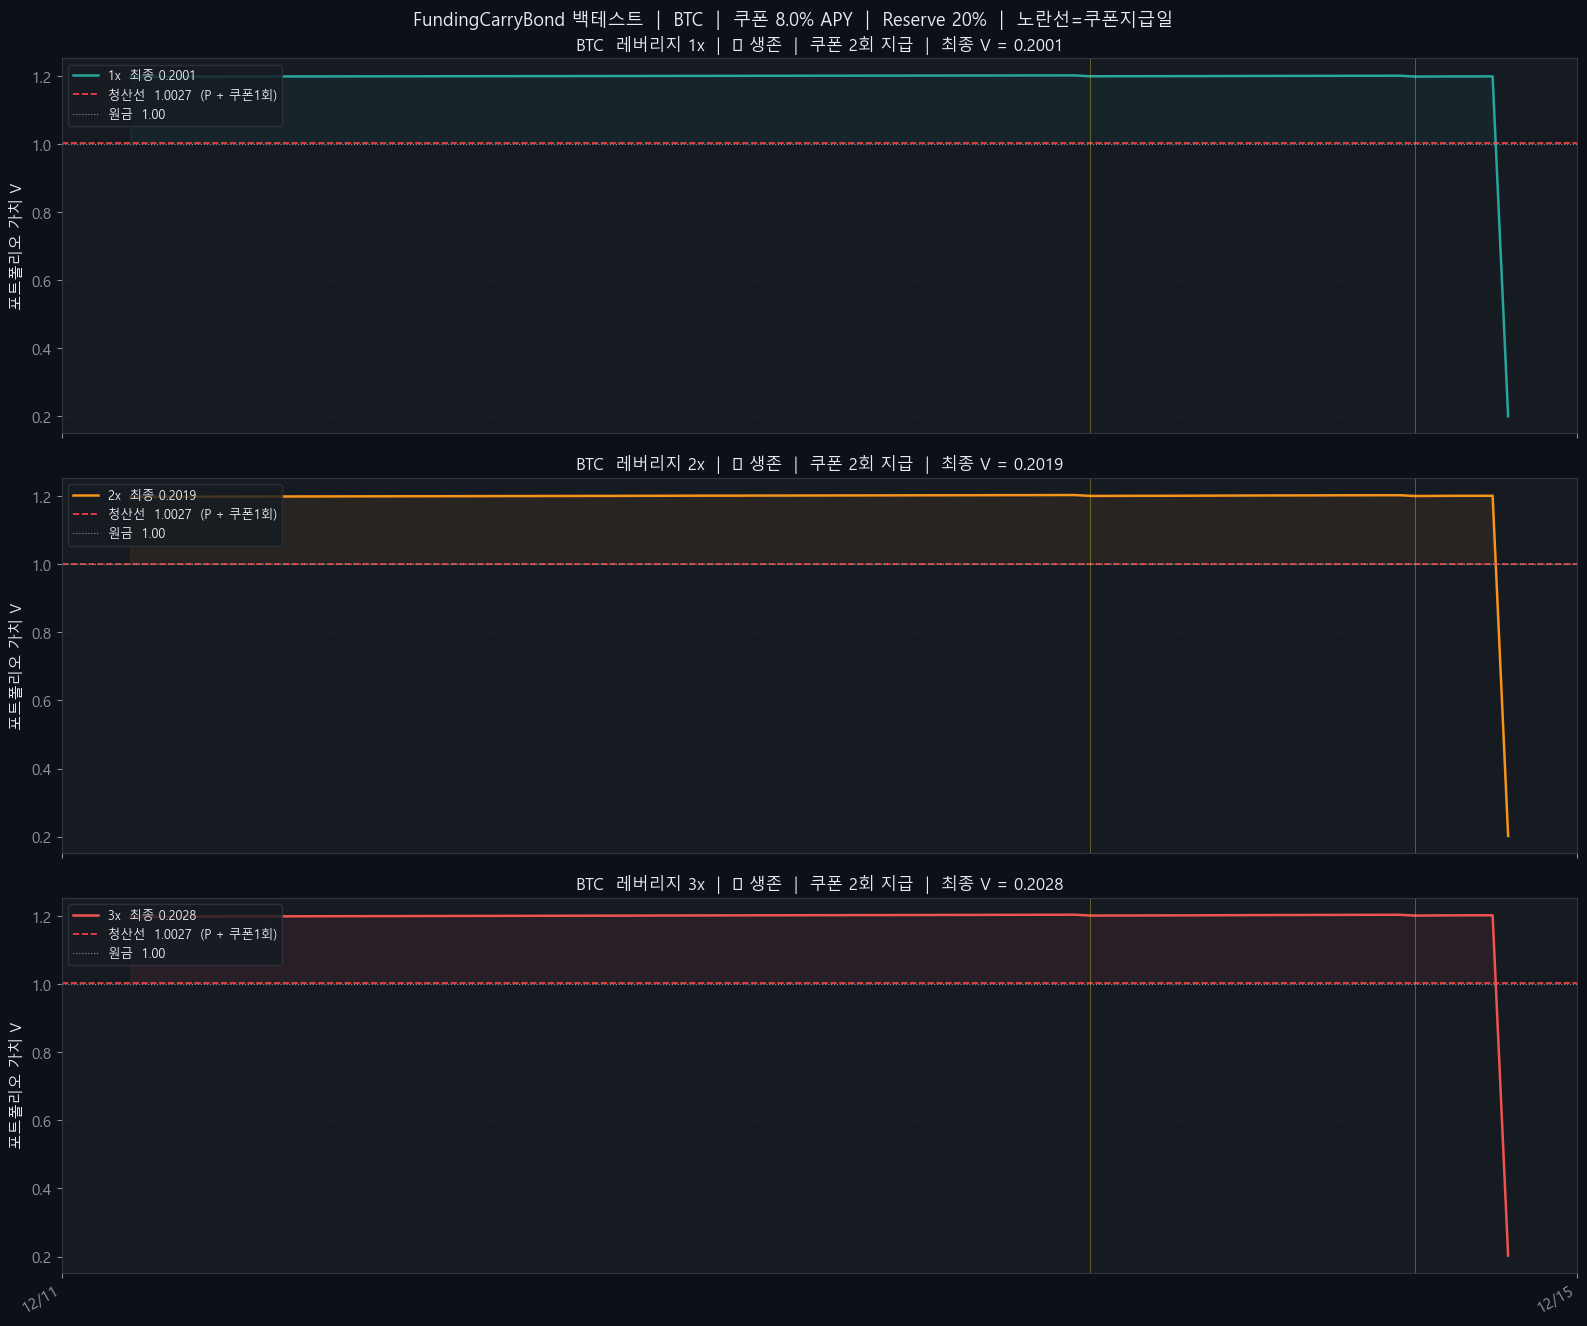

In [166]:
LEV_COLORS = {1: '#26a69a', 2: '#f7931a', 3: '#ef5350'}

fig, axes = plt.subplots(len(BT_LEVERAGES), 1,
                         figsize=(16, 4.5 * len(BT_LEVERAGES)), sharex=True)
if len(BT_LEVERAGES) == 1: axes = [axes]

for ax, lev in zip(axes, BT_LEVERAGES):
    r     = results[lev]
    df_r  = r['df']
    color = LEV_COLORS.get(lev, '#aaaaaa')

    # 포트폴리오 가치
    ax.plot(df_r.index, df_r['V'], color=color, lw=1.8,
            label=f'{lev}x  최종 {r["final_V"]:.4f}')

    # 청산 트리거 선 (P + 쿠폰 1회)
    ax.axhline(LIQ_THRESHOLD, color='#ff4444', lw=1.2, ls='--',
               label=f'청산선  {LIQ_THRESHOLD:.4f}  (P + 쿠폰1회)')

    # 원금 선
    ax.axhline(P, color='#8b949e', lw=0.8, ls=':',
               label=f'원금  {P:.2f}')

    # 쿠폰 지급 시점 표시
    for ct in r['coupon_events']:
        ax.axvline(ct, color='#f0e130', lw=0.6, alpha=0.4)

    # 청산 발생 시 표시
    if r['liquidated']:
        ax.axvline(r['liq_time'], color='#ff0000', lw=2,
                   label=f'청산 발생 {str(r["liq_time"])[:10]}')
        ax.fill_between(df_r.index, df_r['V'], LIQ_THRESHOLD,
                        where=(df_r['V'] < LIQ_THRESHOLD),
                        color='#ff0000', alpha=0.2)

    # 안전 구간 음영
    ax.fill_between(df_r.index, df_r['V'], LIQ_THRESHOLD,
                    where=(df_r['V'] >= LIQ_THRESHOLD),
                    color=color, alpha=0.08)

    flag = '❌ 청산됨' if r['liquidated'] else '✅ 생존'
    ax.set_title(
        f'{BT_COIN}  레버리지 {lev}x  |  {flag}  '
        f'|  쿠폰 {r["coupons_paid"]}회 지급  '
        f'|  최종 V = {r["final_V"]:.4f}',
        fontsize=12
    )
    ax.set_ylabel('포트폴리오 가치 V')
    ax.legend(loc='upper left', fontsize=9,
              facecolor='#161b22', edgecolor='#30363d')
    ax.grid(True)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle(
    f'FundingCarryBond 백테스트  |  {BT_COIN}  |  '
    f'쿠폰 {BT_TARGET_APY}% APY  |  Reserve {BT_R_RATIO*100:.0f}%  |  '
    f'노란선=쿠폰지급일',
    fontsize=13
)
plt.tight_layout()
plt.savefig('chart_backtest.png', dpi=150, bbox_inches='tight')
plt.show()


In [167]:
print('=' * 62)
print(f'  FundingCarryBond 실현 가능성 분석  ({DAYS}일 히스토리)')
print('=' * 62)

for coin in COINS:
    df   = data[coin]
    r    = df['fundingRate']
    ann  = r.mean() * PER_YEAR * 100
    be   = (r.sum() / len(r) * PER_YEAR - fee_cost / (DAYS / 365)) * 100
    flag = '✅' if ann > TARGET_APY else '⚠️'
    print(f'  {flag} {coin:5s}  연환산 {ann:6.2f}%  '
          f'(목표 {TARGET_APY}%  →  여유 {ann - TARGET_APY:+.2f}%)')

print()
print(f'  진입·청산 비용 : {ENTRY_FEE_BP}bp  ({fee_cost*100:.4f}%)')
print(f'  목표 쿠폰 APY  : {TARGET_APY}%')
print('=' * 62)

  FundingCarryBond 실현 가능성 분석  (180일 히스토리)
  ⚠️ BTC    연환산   7.79%  (목표 8.0%  →  여유 -0.21%)
  ✅ ETH    연환산   9.09%  (목표 8.0%  →  여유 +1.09%)
  ✅ HYPE   연환산  12.09%  (목표 8.0%  →  여유 +4.09%)

  진입·청산 비용 : 11.5bp  (0.1150%)
  목표 쿠폰 APY  : 8.0%
